# Restaurant Branch Performance — Exploratory Data Analysis

## Task 13 | Pandas EDA

This notebook performs an Exploratory Data Analysis (EDA) of the **Restaurant Branch Performance Dataset**.

### EDA goals
- Understand the structure and quality of the dataset.
- Review summary statistics and descriptive measures.
- Analyze distributions of important numerical variables.
- Compare performance across branches, regions, store types, days, months, weather conditions, and promotions.
- Use a numerical correlation matrix to identify meaningful relationships.
- Finish with 5–8 data driven observations.

> **Scope:** This is an EDA notebook. No model training, feature scaling, or categorical encoding is required. The categorical columns are analyzed directly using counts and grouped summaries.


## 1. Import Libraries

The analysis uses:
- **Pandas** for data loading, inspection, aggregation, descriptive statistics, and correlation analysis.
- **NumPy** for numerical operations.
- **Matplotlib** for visualizing distributions and comparisons.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


## 2. Load the Dataset

The dataset is loaded from the provided CSV file.

In [4]:
file_path = "Day13_Restaurant_Branch_Performance_Dataset.csv"

df = pd.read_csv(file_path)
df["Date"] = pd.to_datetime(df["Date"])

df.head()


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,"4,977.25",172,135,375.75,"66,766.77","27,954.29","46,554.90","20,211.87",29.00,4.44,20.80,70.30,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,"8,998.30",285,263,530.64,"157,230.89","63,816.59","96,813.95","60,416.94",27.90,4.56,31.30,70.70,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,"10,034.97",306,264,534.97,"155,811.96","54,874.10","89,888.91","65,923.05",30.20,4.36,21.40,61.50,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,"5,095.84",198,167,370.05,"80,574.05","31,429.44","53,531.82","27,042.23",21.70,4.65,22.90,40.40,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,"6,681.82",148,116,364.62,"56,579.89","21,759.51","44,376.25","12,203.64",26.10,4.50,29.00,44.30,Clear,Combo Deal


## 3. Understand the Dataset

The first checks are the dataset shape, data types, and basic structure.


In [5]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes)

print("\nDataFrame information:")
df.info()


Shape: (350, 22)

Data types:


,0
Record_ID,object
Date,datetime64[ns]
Day,object
Month,object
Branch,object
Region,object
Store_Type,object
Staff_Count,int64
Marketing_Spend,float64
Customers,int64



DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Record_ID         350 non-null    object        
 1   Date              350 non-null    datetime64[ns]
 2   Day               350 non-null    object        
 3   Month             350 non-null    object        
 4   Branch            350 non-null    object        
 5   Region            350 non-null    object        
 6   Store_Type        350 non-null    object        
 7   Staff_Count       350 non-null    int64         
 8   Marketing_Spend   350 non-null    float64       
 9   Customers         350 non-null    int64         
 10  Orders            350 non-null    int64         
 11  Average_Bill      350 non-null    float64       
 12  Revenue           350 non-null    float64       
 13  Food_Cost         350 non-null    float64       
 14  Op

In [6]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())


First 5 rows:


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,"4,977.25",172,135,375.75,"66,766.77","27,954.29","46,554.90","20,211.87",29.00,4.44,20.80,70.30,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,"8,998.30",285,263,530.64,"157,230.89","63,816.59","96,813.95","60,416.94",27.90,4.56,31.30,70.70,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,"10,034.97",306,264,534.97,"155,811.96","54,874.10","89,888.91","65,923.05",30.20,4.36,21.40,61.50,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,"5,095.84",198,167,370.05,"80,574.05","31,429.44","53,531.82","27,042.23",21.70,4.65,22.90,40.40,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,"6,681.82",148,116,364.62,"56,579.89","21,759.51","44,376.25","12,203.64",26.10,4.50,29.00,44.30,Clear,Combo Deal



Last 5 rows:


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
345,ST0346,2026-02-08,Sunday,February,Mumbai,West,Express,10,"7,389.17",202,164,322.03,"56,852.25","18,863.88","43,733.92","13,118.33",27.20,4.63,28.90,64.60,Rain,NaN
346,ST0347,2026-06-05,Friday,June,Mumbai,West,Premium,12,"8,398.13",274,232,508.32,"138,198.35","50,914.04","75,370.62","62,827.73",35.40,4.32,22.70,57.90,Rain,NaN
347,ST0348,2026-03-13,Friday,March,Bengaluru,South,Standard,16,"2,876.93",196,183,322.37,"62,974.97","23,946.23","51,377.97","11,597.00",22.50,4.51,32.30,63.40,Clear,Combo Deal
348,ST0349,2026-03-10,Tuesday,March,Jaipur,North,Standard,9,"4,731.74",200,181,413.05,"78,451.05","26,050.73","47,400.29","31,050.76",28.30,4.51,24.70,58.60,Clear,Loyalty Offer
349,ST0350,2026-02-03,Tuesday,February,Pune,West,Standard,16,"7,004.28",225,204,381.10,"86,122.21","28,144.81","54,734.11","31,388.10",22.70,4.30,32.00,83.90,Clear,NaN


### Missing values and duplicate records

Day 13 emphasizes understanding the dataset before deeper analysis. Missing values are checked before calculating summaries.

The `Promotion` column contains missing values. Because the source dataset does not explicitly define missing promotion entries as a separate category, the EDA keeps those values as missing rather than silently relabeling them.


In [7]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percent": missing_pct
})

display(missing_summary[missing_summary["Missing_Count"] > 0])

print("Duplicate rows:", df.duplicated().sum())


,Missing_Count,Missing_Percent
Promotion,184,52.57


Duplicate rows: 0


## 4. Summary Statistics

`describe()` gives the main descriptive statistics for numerical variables: count, mean, standard deviation, minimum, quartiles, and maximum.

This helps establish the scale and spread of variables such as customers, revenue, profit, marketing spend, staff count, delivery time, and customer rating.


In [8]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

summary_stats = df[numerical_columns].describe().T
summary_stats["median"] = df[numerical_columns].median()
summary_stats["skewness"] = df[numerical_columns].skew()

display(summary_stats[[
    "count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "skewness"
]].round(2))


,count,mean,median,std,min,25%,50%,75%,max,skewness
Staff_Count,350.00,11.96,11.00,4.34,5.00,9.00,11.00,15.00,24.00,0.53
Marketing_Spend,350.00,"5,516.35","5,393.37","2,050.91",725.35,"4,339.73","5,393.37","6,748.50","11,784.96",0.10
Customers,350.00,217.38,213.00,56.72,77.00,180.25,213.00,255.75,360.00,0.23
Orders,350.00,187.05,182.50,50.56,71.00,155.00,182.50,218.75,334.00,0.27
Average_Bill,350.00,388.91,383.48,82.49,180.00,337.32,383.48,441.76,623.28,0.31
Revenue,350.00,"86,831.80","79,766.88","36,644.45","20,540.76","61,261.72","79,766.88","102,976.18","194,018.92",0.86
Food_Cost,350.00,"31,807.55","28,861.32","13,896.89","7,262.01","22,326.66","28,861.32","38,370.37","75,946.59",0.93
Operating_Cost,350.00,"56,621.44","53,723.02","18,467.84","20,782.38","43,797.67","53,723.02","63,961.23","111,489.14",0.91
Profit,350.00,"30,210.36","26,873.87","19,508.59","-6,924.68","16,915.49","26,873.87","39,823.74","89,096.19",0.81
Avg_Delivery_Min,350.00,26.10,26.10,4.39,13.90,22.80,26.10,29.08,38.30,0.14


## 5. Categorical Descriptive Analysis

For categorical variables, `value_counts()` shows how observations are distributed among branches, regions, store types, weather conditions, days, months, and promotions.


In [9]:
categorical_columns = [
    "Day", "Month", "Branch", "Region", "Store_Type", "Weather", "Promotion"
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    display(df[column].value_counts(dropna=False).rename("Count").to_frame())



--- Day ---


,Count
Day,
Tuesday,56
Saturday,55
Monday,54
Wednesday,50
Friday,47
Sunday,47
Thursday,41



--- Month ---


,Count
Month,
February,65
January,62
June,61
March,58
April,56
May,48



--- Branch ---


...

,Count
Store_Type,
Standard,196
Express,102
Premium,52



--- Weather ---


,Count
Weather,
Clear,189
Cloudy,82
Rain,48
Hot,31



--- Promotion ---


,Count
Promotion,
NaN,184
Weekend Offer,74
Combo Deal,59
Loyalty Offer,33


## 6. Distribution Analysis

Univariate analysis studies one variable at a time. Histograms help identify concentration, spread, and skewness, while boxplots help inspect the middle 50% of observations and potential outliers.

The focus here is on the business variables requested in the task.


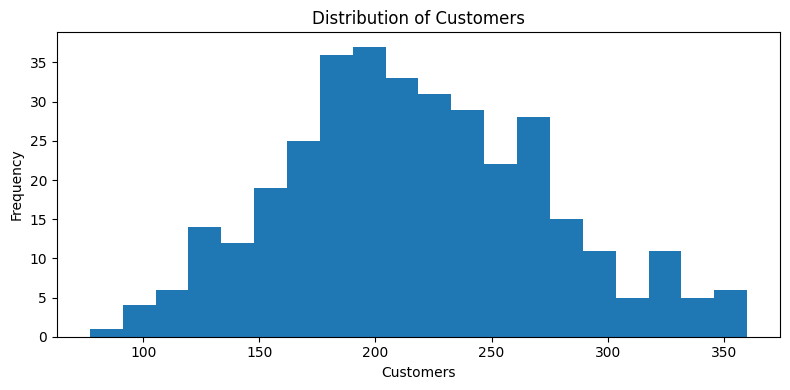

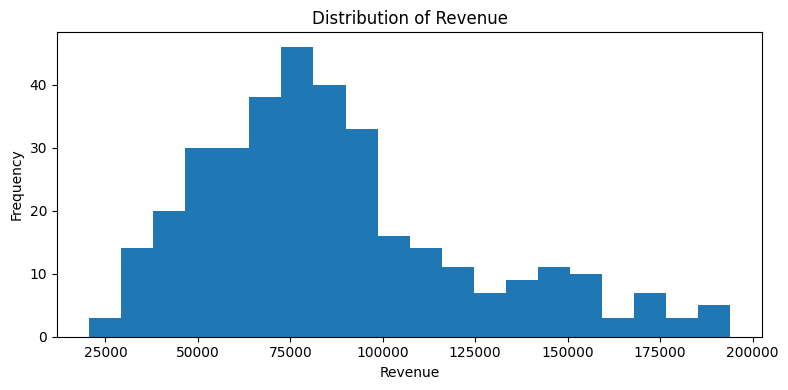

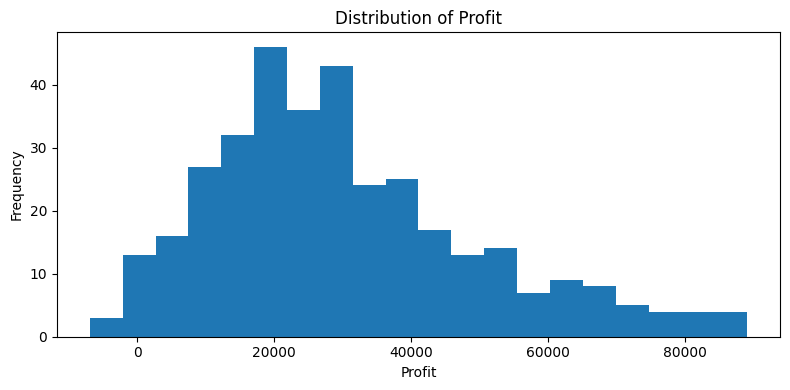

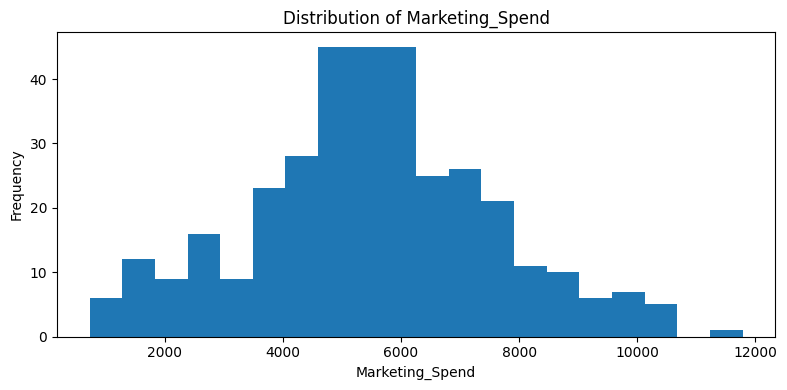

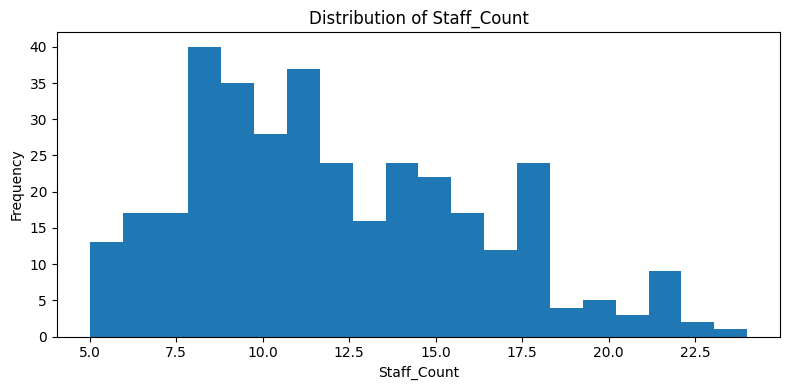

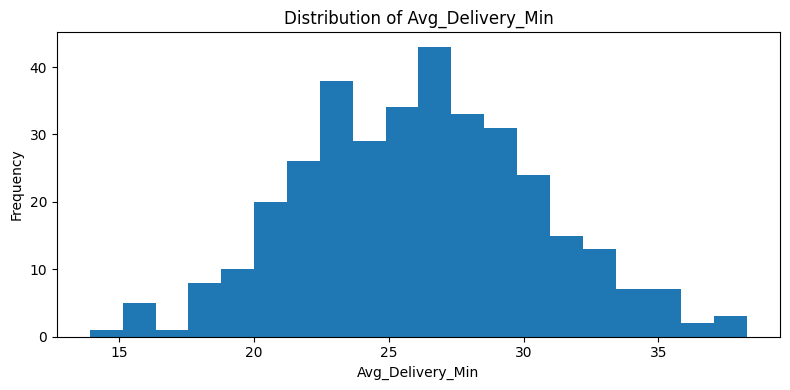

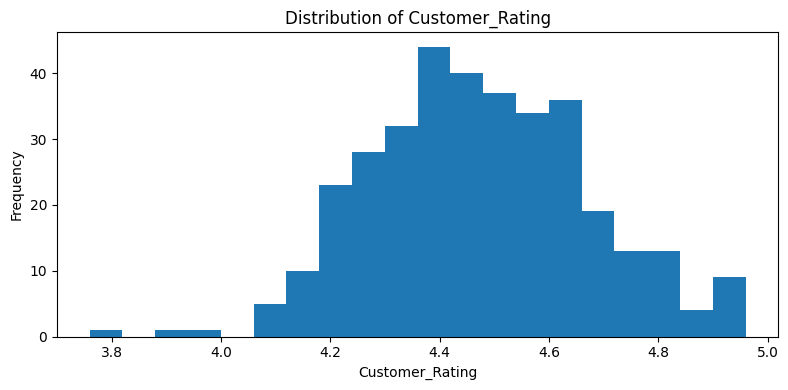

In [10]:
distribution_columns = [
    "Customers", "Revenue", "Profit", "Marketing_Spend",
    "Staff_Count", "Avg_Delivery_Min", "Customer_Rating"
]

for column in distribution_columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(df[column], bins=20)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show()


### Boxplots and IQR-based outlier inspection

The Day 13 notes introduce the IQR method:

- `IQR = Q3 - Q1`
- Lower bound = `Q1 - 1.5 × IQR`
- Upper bound = `Q3 + 1.5 × IQR`

This section counts potential IQR outliers without deleting or modifying them. Outliers can represent legitimate high performing or low performing observations, so they are interpreted rather than automatically removed.


In [11]:
outlier_rows = []

for column in numerical_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[column] < lower) | (df[column] > upper)).sum()
    outlier_rows.append([column, q1, q3, iqr, lower, upper, count])

outlier_summary = pd.DataFrame(
    outlier_rows,
    columns=["Variable", "Q1", "Q3", "IQR", "Lower_Bound", "Upper_Bound", "IQR_Outliers"]
)

display(outlier_summary.sort_values("IQR_Outliers", ascending=False).round(2))


,Variable,Q1,Q3,IQR,Lower_Bound,Upper_Bound,IQR_Outliers
7,Operating_Cost,"43,797.67","63,961.23","20,163.56","13,552.33","94,206.56",18
5,Revenue,"61,261.72","102,976.18","41,714.47","-1,309.98","165,547.89",15
6,Food_Cost,"22,326.66","38,370.37","16,043.71","-1,738.90","62,435.93",13
8,Profit,"16,915.49","39,823.74","22,908.25","-17,446.88","74,186.12",12
1,Marketing_Spend,"4,339.73","6,748.50","2,408.77",726.57,"10,361.66",5
4,Average_Bill,337.32,441.76,104.45,180.64,598.44,4
3,Orders,155.00,218.75,63.75,59.38,314.38,3
11,Temperature_C,24.40,31.00,6.60,14.50,40.90,2
10,Customer_Rating,4.32,4.60,0.28,3.90,5.02,1
2,Customers,180.25,255.75,75.50,67.00,369.00,0


/tmp/ipykernel_602/3486507947.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([df[c] for c in boxplot_columns], labels=boxplot_columns)


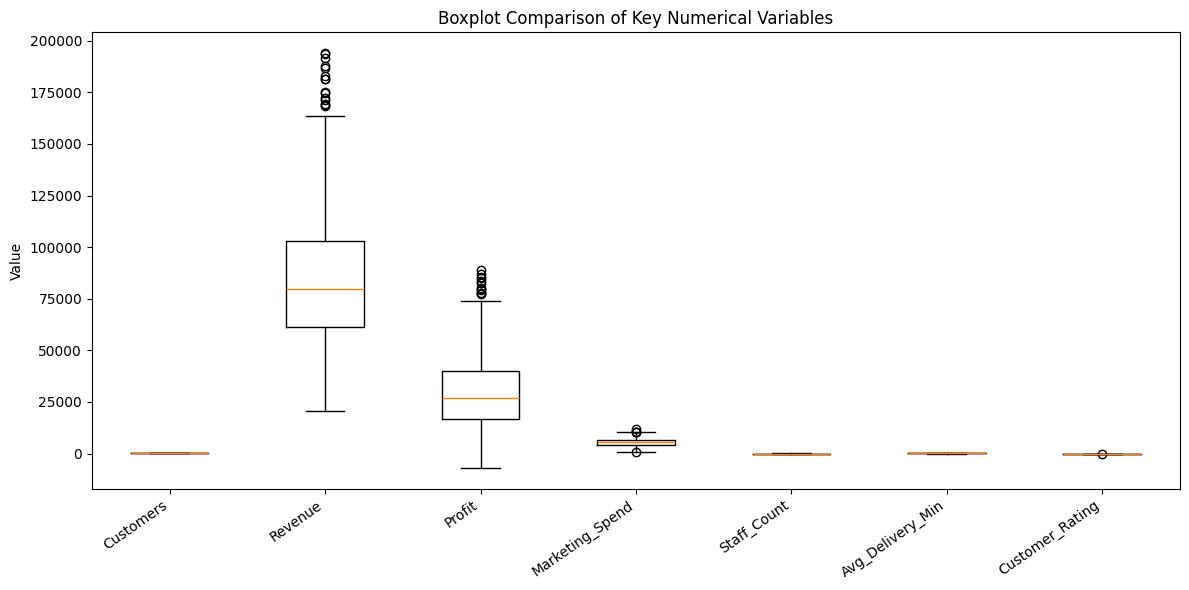

In [12]:
boxplot_columns = [
    "Customers", "Revenue", "Profit", "Marketing_Spend",
    "Staff_Count", "Avg_Delivery_Min", "Customer_Rating"
]

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot([df[c] for c in boxplot_columns], labels=boxplot_columns)
ax.set_title("Boxplot Comparison of Key Numerical Variables")
ax.set_ylabel("Value")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 7. Branch Performance Analysis

Branch-level comparisons are made using **mean** values as well as observation counts. Mean performance is useful because the number of records is not identical across branches.


In [13]:
branch_performance = df.groupby("Branch").agg(
    Records=("Record_ID", "count"),
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Marketing_Spend=("Marketing_Spend", "mean"),
    Avg_Staff_Count=("Staff_Count", "mean"),
    Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
    Avg_Rating=("Customer_Rating", "mean")
).sort_values("Avg_Profit", ascending=False)

display(branch_performance.round(2))


,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Marketing_Spend,Avg_Staff_Count,Avg_Delivery_Min,Avg_Rating
Branch,,,,,,,,
Bengaluru,46,227.50,"90,732.12","31,890.91","5,413.93",12.85,26.56,4.47
Hyderabad,43,220.79,"88,804.90","31,402.98","5,455.15",12.28,25.52,4.47
Delhi,32,213.97,"87,573.87","31,385.30","5,762.63",11.56,25.69,4.49
Pune,37,214.92,"88,107.49","31,265.57","5,590.57",11.86,25.53,4.54
Jaipur,48,223.27,"86,746.16","30,469.70","5,356.64",11.71,26.58,4.47
Srinagar,52,214.73,"86,746.47","30,302.92","5,413.67",12.46,25.97,4.48
Kochi,48,209.06,"85,574.62","28,902.04","5,660.43",11.83,25.84,4.42
Mumbai,44,213.77,"80,779.25","26,580.99","5,580.10",10.89,26.86,4.44


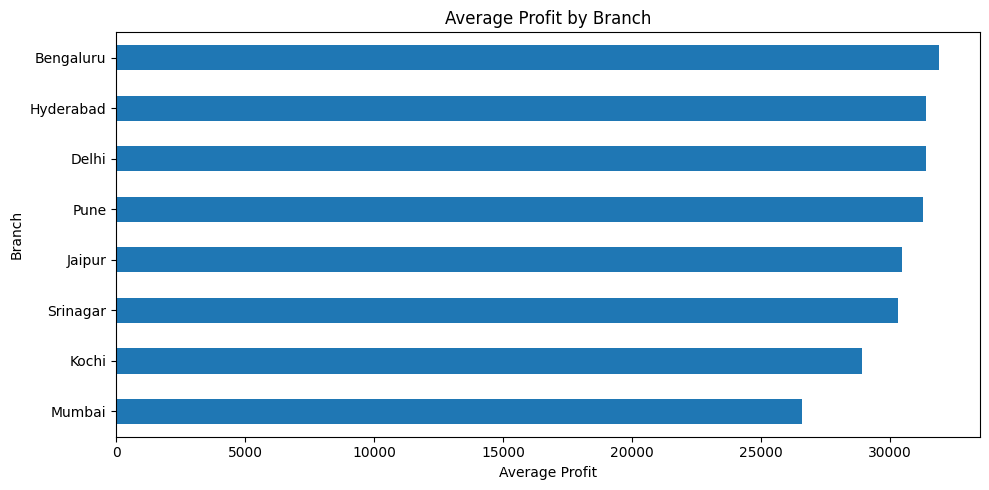

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
branch_performance["Avg_Profit"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Average Profit by Branch")
ax.set_xlabel("Average Profit")
ax.set_ylabel("Branch")
plt.tight_layout()
plt.show()


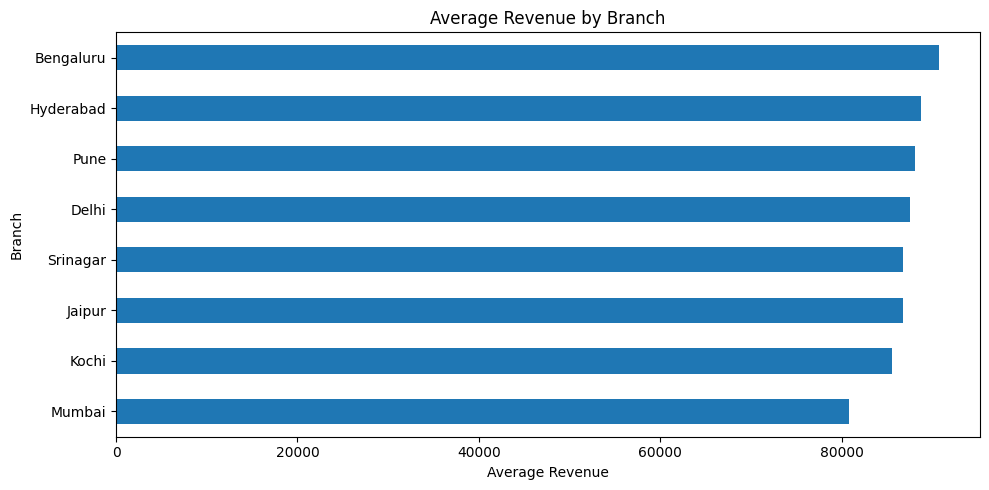

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
branch_performance["Avg_Revenue"].sort_values().plot(kind="barh", ax=ax)
ax.set_title("Average Revenue by Branch")
ax.set_xlabel("Average Revenue")
ax.set_ylabel("Branch")
plt.tight_layout()
plt.show()


## 8. Regional Performance Analysis

Region-level aggregation helps identify whether broad geographic groupings differ in customer volume, revenue, profitability, delivery time, and ratings.


In [16]:
region_performance = df.groupby("Region").agg(
    Records=("Record_ID", "count"),
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Marketing_Spend=("Marketing_Spend", "mean"),
    Avg_Staff_Count=("Staff_Count", "mean"),
    Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
    Avg_Rating=("Customer_Rating", "mean")
).sort_values("Avg_Profit", ascending=False)

display(region_performance.round(2))


,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Marketing_Spend,Avg_Staff_Count,Avg_Delivery_Min,Avg_Rating
Region,,,,,,,,
South,137,218.93,"88,320.22","30,690.57","5,513.23",12.31,25.98,4.45
North,132,217.65,"86,946.94","30,625.96","5,477.53",11.97,26.13,4.48
West,81,214.30,"84,126.72","28,720.86","5,584.88",11.33,26.25,4.49


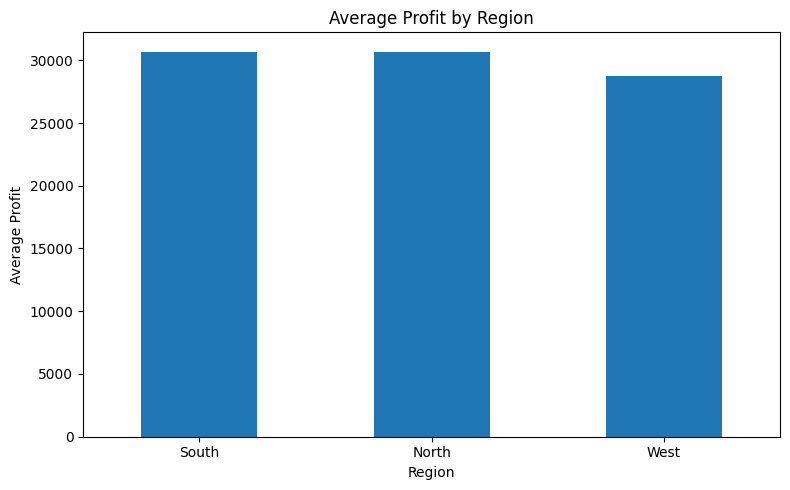

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
region_performance["Avg_Profit"].plot(kind="bar", ax=ax)
ax.set_title("Average Profit by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Average Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Store Type Performance

Store types can have very different operating scales. Therefore, both record counts and average performance are shown rather than relying only on totals.


In [18]:
store_performance = df.groupby("Store_Type").agg(
    Records=("Record_ID", "count"),
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Marketing_Spend=("Marketing_Spend", "mean"),
    Avg_Staff_Count=("Staff_Count", "mean"),
    Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
    Avg_Rating=("Customer_Rating", "mean")
).sort_values("Avg_Profit", ascending=False)

display(store_performance.round(2))


,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Marketing_Spend,Avg_Staff_Count,Avg_Delivery_Min,Avg_Rating
Store_Type,,,,,,,,
Premium,52,298.73,"152,867.31","62,890.24","8,065.56",17.60,26.40,4.46
Standard,196,224.98,"87,268.67","30,630.79","5,044.90",12.54,25.98,4.47
Express,102,161.29,"52,327.16","12,742.14","5,122.66",7.96,26.17,4.46


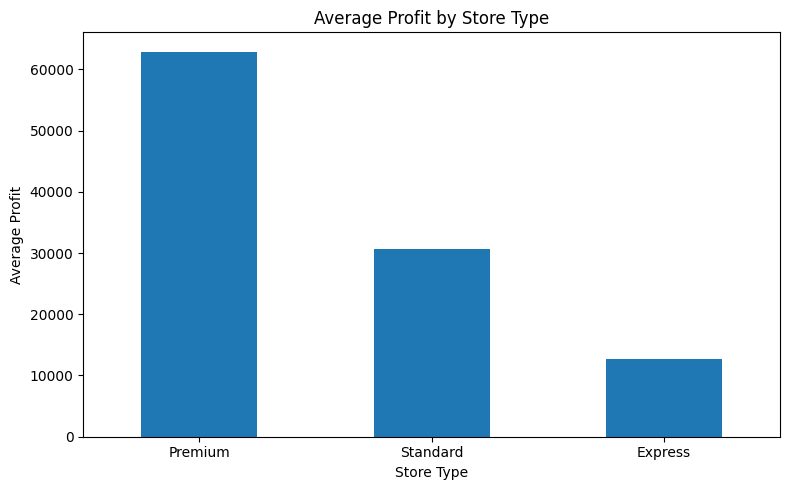

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
store_performance["Avg_Profit"].plot(kind="bar", ax=ax)
ax.set_title("Average Profit by Store Type")
ax.set_xlabel("Store Type")
ax.set_ylabel("Average Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 10. Day and Month Comparisons

The dataset contains operational observations across six months and all days of the week. Grouped means help identify temporal patterns in customer volume, revenue, and profit.


In [20]:
day_performance = df.groupby("Day").agg(
    Records=("Record_ID", "count"),
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
    Avg_Rating=("Customer_Rating", "mean")
)

display(day_performance.round(2))


,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Delivery_Min,Avg_Rating
Day,,,,,,
Friday,47,200.72,"80,418.65","27,033.10",25.18,4.50
Monday,54,202.24,"79,398.29","26,416.72",26.07,4.49
Saturday,55,251.75,"99,643.14","37,695.28",27.24,4.47
Sunday,47,256.66,"101,835.93","38,698.20",27.70,4.43
Thursday,41,206.85,"81,236.42","27,668.98",26.44,4.45
Tuesday,56,202.50,"83,801.58","26,958.94",24.06,4.48
Wednesday,50,199.94,"80,674.05","26,807.62",26.23,4.44


In [21]:
month_performance = df.groupby("Month").agg(
    Records=("Record_ID", "count"),
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
    Avg_Rating=("Customer_Rating", "mean")
)

display(month_performance.round(2))


,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Delivery_Min,Avg_Rating
Month,,,,,,
April,56,219.12,"88,531.11","30,100.44",25.62,4.45
February,65,218.02,"87,147.27","30,256.80",26.79,4.44
January,62,213.82,"84,384.44","29,012.63",26.30,4.48
June,61,207.90,"78,780.56","25,887.55",26.13,4.47
March,58,216.19,"86,936.61","31,550.08",25.72,4.50
May,48,232.54,"97,688.38","35,697.50",25.87,4.46


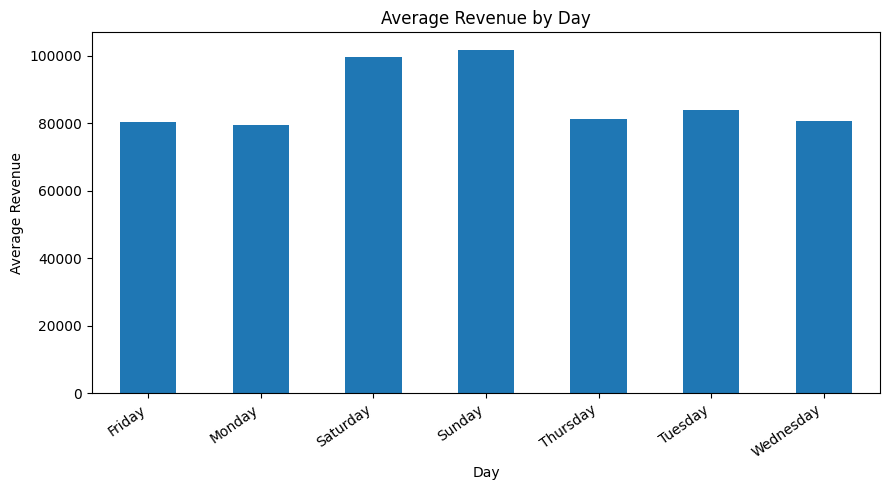

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
day_performance["Avg_Revenue"].plot(kind="bar", ax=ax)
ax.set_title("Average Revenue by Day")
ax.set_xlabel("Day")
ax.set_ylabel("Average Revenue")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## 11. Marketing, Staffing, Delivery, and Ratings

The following grouped summaries focus on operational factors specifically highlighted in the task.


In [23]:
operational_summary = df[[
    "Marketing_Spend", "Staff_Count", "Customers", "Revenue",
    "Profit", "Avg_Delivery_Min", "Customer_Rating"
]].describe().T

display(operational_summary.round(2))


,count,mean,std,min,25%,50%,75%,max
Marketing_Spend,350.00,"5,516.35","2,050.91",725.35,"4,339.73","5,393.37","6,748.50","11,784.96"
Staff_Count,350.00,11.96,4.34,5.00,9.00,11.00,15.00,24.00
Customers,350.00,217.38,56.72,77.00,180.25,213.00,255.75,360.00
Revenue,350.00,"86,831.80","36,644.45","20,540.76","61,261.72","79,766.88","102,976.18","194,018.92"
Profit,350.00,"30,210.36","19,508.59","-6,924.68","16,915.49","26,873.87","39,823.74","89,096.19"
Avg_Delivery_Min,350.00,26.10,4.39,13.90,22.80,26.10,29.08,38.30
Customer_Rating,350.00,4.47,0.20,3.76,4.32,4.47,4.60,4.96


In [24]:
# Compare average performance across promotion categories.
promotion_performance = df.groupby("Promotion", dropna=False).agg(
    Records=("Record_ID", "count"),
    Avg_Customers=("Customers", "mean"),
    Avg_Revenue=("Revenue", "mean"),
    Avg_Profit=("Profit", "mean"),
    Avg_Marketing_Spend=("Marketing_Spend", "mean"),
    Avg_Delivery_Min=("Avg_Delivery_Min", "mean"),
    Avg_Rating=("Customer_Rating", "mean")
).sort_values("Avg_Profit", ascending=False)

display(promotion_performance.round(2))


,Records,Avg_Customers,Avg_Revenue,Avg_Profit,Avg_Marketing_Spend,Avg_Delivery_Min,Avg_Rating
Promotion,,,,,,,
Loyalty Offer,33,226.97,"91,937.89","32,346.09","5,746.03",26.35,4.44
Weekend Offer,74,224.54,"88,808.72","31,730.63","5,592.81",26.96,4.45
Combo Deal,59,218.64,"86,269.73","29,779.94","5,467.60",25.73,4.45
NaN,184,212.37,"85,301.20","29,353.92","5,460.04",25.82,4.49


## 12. Correlation Analysis

Correlation measures the strength and direction of a linear relationship between two numerical variables.

- Values close to **+1** indicate a strong positive linear relationship.
- Values close to **-1** indicate a strong negative linear relationship.
- Values near **0** indicate little linear relationship.

The correlation matrix below uses numerical variables only. Correlation does **not** establish causation.


In [25]:
correlation_matrix = df[numerical_columns].corr()

display(correlation_matrix.round(3))


,Staff_Count,Marketing_Spend,Customers,Orders,Average_Bill,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent
Staff_Count,1.00,0.28,0.69,0.67,0.52,0.69,0.68,0.79,0.56,-0.18,0.08,0.08,-0.02
Marketing_Spend,0.28,1.00,0.41,0.42,0.33,0.43,0.41,0.48,0.35,0.10,-0.06,0.06,-0.05
Customers,0.69,0.41,1.00,0.98,0.53,0.88,0.84,0.86,0.84,0.18,-0.05,0.00,-0.10
Orders,0.67,0.42,0.98,1.00,0.52,0.86,0.83,0.84,0.81,0.19,-0.05,0.02,-0.09
Average_Bill,0.52,0.33,0.53,0.52,1.00,0.84,0.84,0.80,0.83,-0.03,0.04,-0.05,-0.04
Revenue,0.69,0.43,0.88,0.86,0.84,1.00,0.98,0.96,0.97,0.08,0.01,-0.03,-0.09
Food_Cost,0.68,0.41,0.84,0.83,0.84,0.98,1.00,0.97,0.92,0.08,0.00,-0.03,-0.08
Operating_Cost,0.79,0.48,0.86,0.84,0.80,0.96,0.97,1.00,0.86,0.02,0.02,0.01,-0.07
Profit,0.56,0.35,0.84,0.81,0.83,0.97,0.92,0.86,1.00,0.13,-0.01,-0.06,-0.11
Avg_Delivery_Min,-0.18,0.10,0.18,0.19,-0.03,0.08,0.08,0.02,0.13,1.00,-0.44,0.01,-0.11


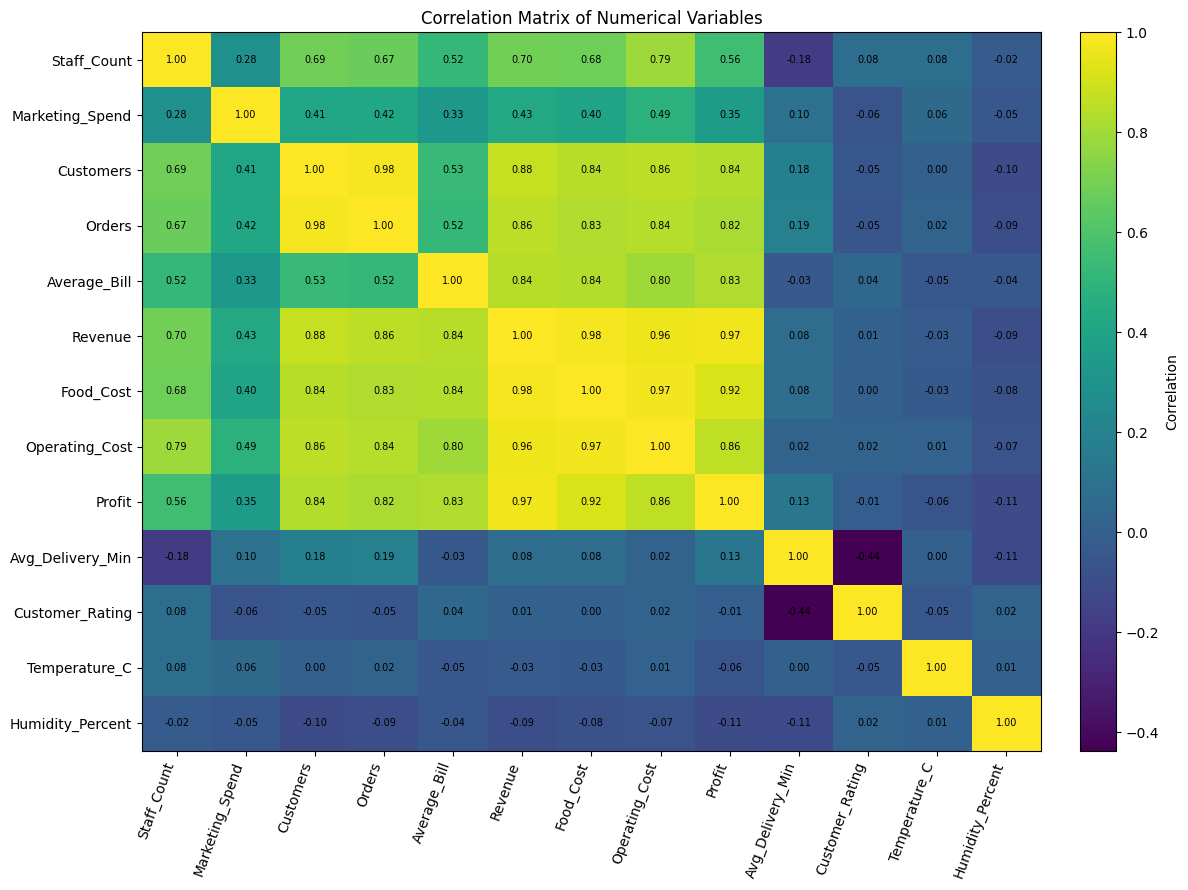

In [26]:
fig, ax = plt.subplots(figsize=(12, 9))
image = ax.imshow(correlation_matrix, aspect="auto")

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_xticklabels(correlation_matrix.columns, rotation=70, ha="right")
ax.set_yticklabels(correlation_matrix.index)
ax.set_title("Correlation Matrix of Numerical Variables")

# Add correlation values inside cells.
for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=7)

fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Correlation")
plt.tight_layout()
plt.show()


### Strongest correlations

To avoid relying only on visual inspection, the strongest absolute correlations are listed below. The diagonal self-correlations are excluded.


In [27]:
pairs = []

for i, col1 in enumerate(numerical_columns):
    for j, col2 in enumerate(numerical_columns):
        if j > i:
            value = correlation_matrix.loc[col1, col2]
            pairs.append((col1, col2, value, abs(value)))

strongest_correlations = (
    pd.DataFrame(pairs, columns=["Variable_1", "Variable_2", "Correlation", "Absolute_Correlation"])
    .sort_values("Absolute_Correlation", ascending=False)
    .head(15)
)

display(strongest_correlations.round(3))


,Variable_1,Variable_2,Correlation,Absolute_Correlation
23,Customers,Orders,0.98,0.98
50,Revenue,Food_Cost,0.98,0.98
57,Food_Cost,Operating_Cost,0.97,0.97
52,Revenue,Profit,0.97,0.97
51,Revenue,Operating_Cost,0.96,0.96
58,Food_Cost,Profit,0.92,0.92
25,Customers,Revenue,0.88,0.88
63,Operating_Cost,Profit,0.86,0.86
34,Orders,Revenue,0.86,0.86
27,Customers,Operating_Cost,0.86,0.86


## 13. Focused Relationship Checks

The strongest business relevant relationships are visualized with simple scatter plots. This is useful for checking whether the correlation patterns are also visible in the raw observations.


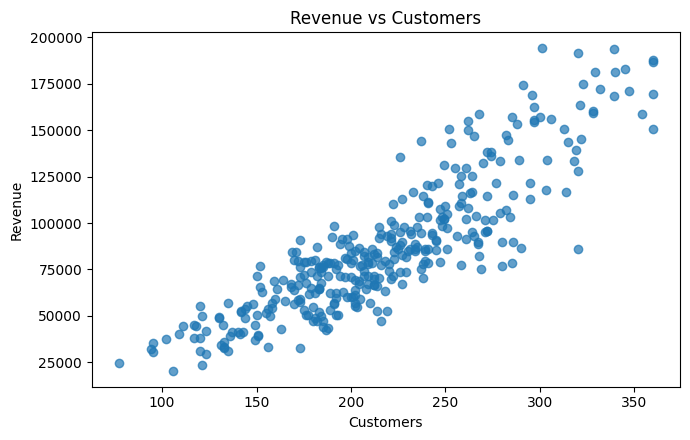

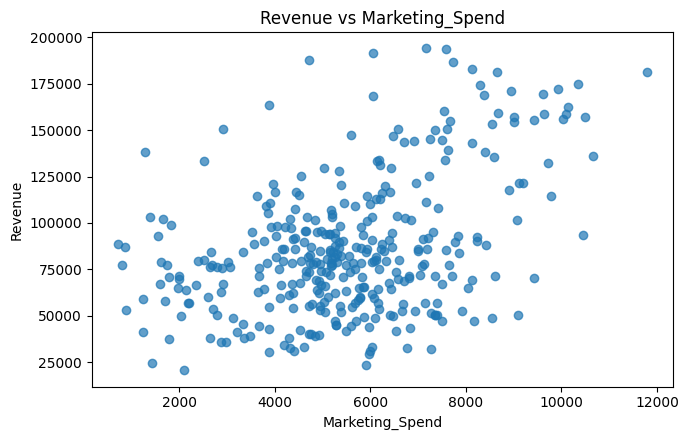

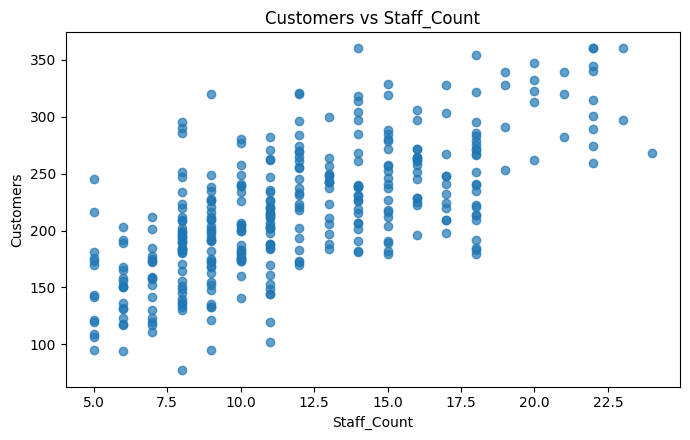

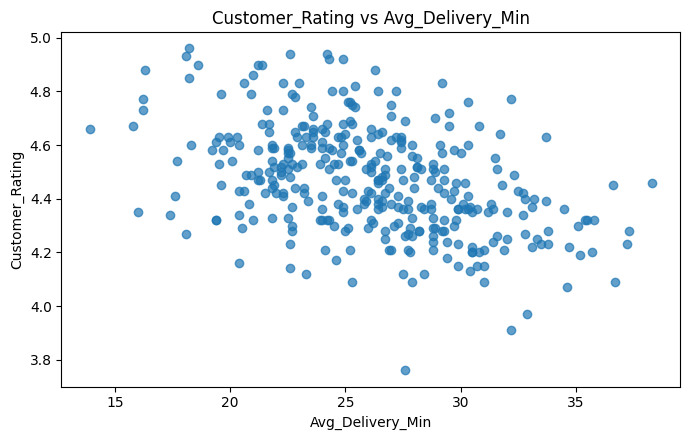

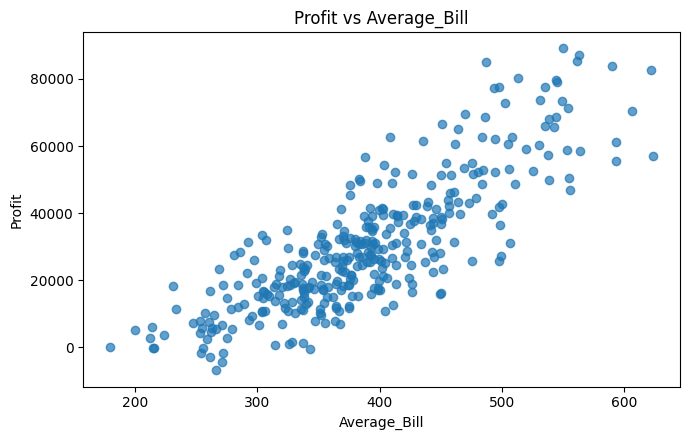

In [28]:
relationship_pairs = [
    ("Customers", "Revenue"),
    ("Marketing_Spend", "Revenue"),
    ("Staff_Count", "Customers"),
    ("Avg_Delivery_Min", "Customer_Rating"),
    ("Average_Bill", "Profit")
]

for x_col, y_col in relationship_pairs:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.scatter(df[x_col], df[y_col], alpha=0.7)
    ax.set_title(f"{y_col} vs {x_col}")
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    plt.tight_layout()
    plt.show()


## 14. Key Data-Driven Observations

1. **Customers and Orders are extremely strongly related.** Their correlation is about **0.98**, indicating that higher customer counts generally coincide with higher order volumes in this dataset.

2. **Revenue is strongly associated with Profit.** The correlation between Revenue and Profit is about **0.97**, while Revenue also has strong positive relationships with Customers and Average_Bill. This indicates that sales volume and bill size are important contributors to financial performance.

3. **Store type is a major performance differentiator.** Premium stores have the highest average revenue and average profit, while Express stores have much lower averages. The comparison should be interpreted alongside record counts because Standard stores are much more numerous in the dataset.

4. **Regional differences are visible but smaller than store type differences.** South has the highest average revenue and profit among the three regions, while West has the lowest average revenue and profit.

5. **Branch performance varies meaningfully.** Bengaluru has the highest average profit among branches, while Kochi has the lowest average profit. Pune records the highest average customer rating.

6. **Marketing spend has a moderate positive relationship with revenue but a much weaker relationship with profit.** The correlation with Revenue is about **0.43**, compared with about **0.35** for Profit. This suggests marketing spend is associated with sales activity, but higher spend alone does not guarantee proportionally higher profit.

7. **Delivery time and customer rating show a moderate negative relationship.** Their correlation is about **-0.44**, suggesting longer average delivery times tend to be associated with lower ratings in these observations. This is an association, not proof that delivery time causes lower ratings.

8. **Profit and revenue distributions are right-skewed.** Revenue, Food_Cost, Operating_Cost, and Profit have noticeable positive skewness and several IQR-based high end outliers, indicating that some observations represent substantially larger operations or unusually strong performance.


## 15. Conclusion

The EDA shows that restaurant performance is driven by a combination of customer/order volume, average bill size, operating scale, and store format. Revenue and profit move closely together, while customers and orders form an especially strong relationship. Store type creates substantial differences in average financial performance, and branch/region comparisons reveal additional variation.

Operationally, marketing spend is positively associated with revenue but only moderately with profit, while delivery time has a noticeable negative relationship with customer ratings. These findings provide useful directions for deeper analysis, such as investigating profitability by store format, optimizing staffing and delivery operations, and evaluating marketing effectiveness while accounting for branch and store type differences.
